# Nettoyage et Anonymisation des Données de Churn

## 1 : CHARGEMENT DES DONNÉES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Charger le fichier
df = pd.read_csv('dataset_churn.csv')

print("Dataset chargé avec succès!")
print(f"Shape initial : {df.shape}")
print(f"\nPremières lignes :")
df.head()


Dataset chargé avec succès!
Shape initial : (2020, 11)

Premières lignes :


,nom_complet,genre,pays,age,revenu_annuel,type_abonnement,duree_abonnement_mois,nb_connexions_mensuelles,dernier_dispositif,derniere_connexion,churn
0,Stephanie Cox,Femme,Belgique,32.0,26657.44€,Standard,28.2,9999,PC,2025-06-20 17:19:27,0
1,Juan Reed,Femme,Belgique,50.0,43826.83,Standard,4.8,19,SmartTV,2025-06-22 02:50:37,1
2,Yolanda David DVM,Femme,Algérie,20.0,33698.53,Familial,11.6,21,PC,2025-04-12 21:20:10,0
3,Mark May,Femme,France,57.0,62953.26€,Standard,11.7,31,Tablette,2025-01-15 13:11:23,0
4,Christopher Richardson,Femme,Algérie,57.0,43161.83€,NaN,13.1,22,SmartTV,2025-07-06 13:24:16,0


In [5]:
print(f"\nInfo sur les colonnes :")
print(df.info())


Info sur les colonnes :
<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   nom_complet               2020 non-null   str    
 1   genre                     2020 non-null   str    
 2   pays                      2020 non-null   str    
 3   age                       1920 non-null   float64
 4   revenu_annuel             1939 non-null   str    
 5   type_abonnement           1905 non-null   str    
 6   duree_abonnement_mois     1949 non-null   float64
 7   nb_connexions_mensuelles  2020 non-null   int64  
 8   dernier_dispositif        1980 non-null   str    
 9   derniere_connexion        2020 non-null   str    
 10  churn                     2020 non-null   int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 173.7 KB
None


## 2 Anonymisation des Données

1. nom_complet : Identifiant direct personnel - Suppression complète
2. dernier_dispositif + derniere_connexion : Combinaison potentiellement ré-identifiante 
3. revenu_annuel : Donnée financière sensible - Binning (regroupement en intervalles) ou perturbation
4. age : Donnée démographique - Binning/Regroupement
5. pays : Données de localisation - Hashage ou Suppression
6. genre : Donnée démographique - Peut être conservée (moins sensible)
 - je dois appliquer les technique apres le netoyage du dataframe

## 3 : SUPPRESSION DES DOUBLONS

In [6]:
# Vérifier les doublons
nb_doublons = df.duplicated().sum()
print(f"\nNombre de lignes AVANT suppression : {len(df)}")
print(f"Nombre de doublons détectés : {nb_doublons}")

# Supprimer les doublons
df = df.drop_duplicates()

print(f"Nombre de lignes APRÈS suppression : {len(df)}")
print(f"Lignes supprimées : {nb_doublons}")
print(f"\nDoublons supprimés avec succès")


Nombre de lignes AVANT suppression : 2020
Nombre de doublons détectés : 20
Nombre de lignes APRÈS suppression : 2000
Lignes supprimées : 20

Doublons supprimés avec succès


## 4 : CORRECTION DE LA COLONNE REVENU

In [7]:
import re

# Fonction pour nettoyer le revenu
def nettoyer_revenu(val):
    if pd.isna(val):
        return np.nan
    
    # Convertir en string et supprimer les espaces
    val_str = str(val).strip()
    
    if val_str == '' or val_str == 'None':
        return np.nan
    
    # Supprimer tous les symboles de devise
    # Garder seulement les chiffres et les séparateurs décimaux
    val_str = re.sub(r'[^\d.,]', '', val_str)
    
    # Harmoniser le séparateur décimal : virgule vers point
    val_str = val_str.replace(',', '.')
    
    try:
        result = float(val_str)
        return result
    except ValueError:
        return np.nan

# Afficher les valeurs AVANT
print(f"\nValeurs AVANT nettoyage (premiers 5) :")
for i in range(min(5, len(df))):
    print(f"  {i}: {df['revenu_annuel'].iloc[i]}")

# Appliquer le nettoyage
df['revenu_annuel'] = df['revenu_annuel'].apply(nettoyer_revenu)

# Afficher les valeurs APRÈS
print(f"\nValeurs APRÈS nettoyage (premiers 5) :")
for i in range(min(5, len(df))):
    print(f"  {i}: {df['revenu_annuel'].iloc[i]}")

print(f"\n" + "-"*80)
print(f"Type après correction : {df['revenu_annuel'].dtype}")
print(f"Valeurs NaN : {df['revenu_annuel'].isna().sum()}")

# Afficher les indices des valeurs NaN
nan_indices = df[df['revenu_annuel'].isna()].index.tolist()
if len(nan_indices) > 0:
    print(f"\nIndices des valeurs NaN/manquantes : {nan_indices[:20]}")
    print(f"Nombre total de NaN : {len(nan_indices)}")
    print(f"\nExemples de lignes avec NaN :")
    print(df[df['revenu_annuel'].isna()][['nom_complet', 'revenu_annuel']].head(10))
else:
    print(f"\n✓ Aucune valeur NaN détectée!")

print(f"\n" + "-"*80)
print(f" vérifier si le valeurs min et max sont correct pour le revenu :")
print(f"  Min : {df['revenu_annuel'].min():.2f}")
print(f"  Max : {df['revenu_annuel'].max():.2f}")
print(f"\n Colonne revenu corrigée")


Valeurs AVANT nettoyage (premiers 5) :
  0: 26657.44€
  1: 43826.83
  2: 33698.53
  3: 62953.26€
  4: 43161.83€

Valeurs APRÈS nettoyage (premiers 5) :
  0: 26657.44
  1: 43826.83
  2: 33698.53
  3: 62953.26
  4: 43161.83

--------------------------------------------------------------------------------
Type après correction : float64
Valeurs NaN : 150

Indices des valeurs NaN/manquantes : [21, 28, 54, 77, 81, 89, 95, 98, 105, 106, 121, 139, 142, 164, 174, 196, 200, 202, 262, 266]
Nombre total de NaN : 150

Exemples de lignes avec NaN :
           nom_complet  revenu_annuel
21   Sherry Johnson MD            NaN
28           Ana Ramos            NaN
54     Mallory Shaffer            NaN
77       Thomas Fields            NaN
81      Frederick Diaz            NaN
89       Kimberly Case            NaN
95           Jon Brown            NaN
98      Lauren Andrews            NaN
105      Lauren Bailey            NaN
106       Robert Lewis            NaN

--------------------------------------

## 5 : TRANSFORMATION DE LA COLONNE derniere_connexion 

In [8]:

print(f"\nType original : {df['derniere_connexion'].dtype}")
print(f"Exemples de valeurs AVANT conversion :")
print(df['derniere_connexion'].head(5))

# convertir en datetime

df['derniere_connexion'] = pd.to_datetime(df['derniere_connexion'])

print(f" Type après conversion : {df['derniere_connexion'].dtype}")
print(f"\nExemples APRÈS conversion :")
print(df['derniere_connexion'].head(5))


Type original : str
Exemples de valeurs AVANT conversion :
0    2025-06-20 17:19:27
1    2025-06-22 02:50:37
2    2025-04-12 21:20:10
3    2025-01-15 13:11:23
4    2025-07-06 13:24:16
Name: derniere_connexion, dtype: str
 Type après conversion : datetime64[us]

Exemples APRÈS conversion :
0   2025-06-20 17:19:27
1   2025-06-22 02:50:37
2   2025-04-12 21:20:10
3   2025-01-15 13:11:23
4   2025-07-06 13:24:16
Name: derniere_connexion, dtype: datetime64[us]


In [9]:
# créer colonne jour_semaine (0=lundi, 6=dimanche)
df['jour_semaine'] = df['derniere_connexion'].dt.dayofweek

# créer colonne mois
df['mois'] = df['derniere_connexion'].dt.month

# Mapping pour affichage lisible
jours = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
mois_dict = {1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
             7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'}

print(f"\nExemples de transformation :")
for idx in range(5):
    date = df.iloc[idx]['derniere_connexion']
    jour = df.iloc[idx]['jour_semaine']
    mois = df.iloc[idx]['mois']
    print(f"  {date} vers: Jour: {jours[jour]} ({jour}), Mois: {mois_dict[mois]} ({mois})")

print(f"\n Distribution des jours de semaine :")
print(df['jour_semaine'].value_counts().sort_index())

print(f"\n Distribution des mois :")
print(df['mois'].value_counts().sort_index())

print(f"\n Colonnes jour_semaine et mois créées avec succès!")


Exemples de transformation :
  2025-06-20 17:19:27 vers: Jour: Vendredi (4), Mois: Juin (6)
  2025-06-22 02:50:37 vers: Jour: Dimanche (6), Mois: Juin (6)
  2025-04-12 21:20:10 vers: Jour: Samedi (5), Mois: Avril (4)
  2025-01-15 13:11:23 vers: Jour: Mercredi (2), Mois: Janvier (1)
  2025-07-06 13:24:16 vers: Jour: Dimanche (6), Mois: Juillet (7)

 Distribution des jours de semaine :
jour_semaine
0    280
1    270
2    293
3    289
4    282
5    307
6    279
Name: count, dtype: int64

 Distribution des mois :
mois
1    317
2    298
3    338
4    313
5    337
6    309
7     88
Name: count, dtype: int64

 Colonnes jour_semaine et mois créées avec succès!


## 6 : ANALYSE DES VALEURS MANQUANTES

In [10]:
# Calculer les valeurs manquantes
valeurs_manquantes = df.isnull().sum()
pourcentage_manquant = (valeurs_manquantes / len(df)) * 100

# Créer un tableau récapitulatif
resume_manquant = pd.DataFrame({
    'Colonne': df.columns,
    'Valeurs manquantes': valeurs_manquantes.values,
    'Pourcentage (%)': pourcentage_manquant.values
})

# Filtrer seulement les colonnes avec des valeurs manquantes
resume_manquant = resume_manquant[resume_manquant['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

print(f"\nColonnes avec valeurs manquantes :")
if len(resume_manquant) == 0:
    print("Aucune valeur manquante détectée! ✓")
else:
    print(resume_manquant.to_string(index=False))



Colonnes avec valeurs manquantes :
              Colonne  Valeurs manquantes  Pourcentage (%)
        revenu_annuel                 150             7.50
      type_abonnement                 113             5.65
                  age                  97             4.85
duree_abonnement_mois                  70             3.50
   dernier_dispositif                  39             1.95


### Stratégies de traitement proposées :
 - Colonne: revenu_annuel
   - Valeurs manquantes: 150 (7.50%)
   - Stratégie: imputer la médiane (colonne numérique)
- Colonne: type_abonnement
   - Valeurs manquantes: 113 (5.65%)
   - Stratégie: imputer le mode (colonne catégorique)
- Colonne: age
   - Valeurs manquantes: 97 (4.85%)
   - Stratégie: imputer la moyenne (distribution continue)
- Colonne: duree_abonnement_mois
   - Valeurs manquantes: 70 (3.50%)
   - Stratégie: imputer la moyenne 
- Colonne: dernier_dispositif
   - Valeurs manquantes: 39 (1.95%)
   - Stratégie: imputation par inconnu

## 6.1 : IMPUTATION DES VALEURS MANQUANTES

In [11]:
# Imputation des valeurs manquantes
print("IMPUTATION DES VALEURS MANQUANTES\n")

# Avant
print(f"Avant  : {df.isnull().sum().sum()} valeurs NaN")

# Imputer
df['revenu_annuel'].fillna(df['revenu_annuel'].median(), inplace=True)
df['type_abonnement'].fillna(df['type_abonnement'].mode()[0], inplace=True)
df['age'].fillna(df['age'].mean(), inplace=True)
df['duree_abonnement_mois'].fillna(df['duree_abonnement_mois'].mean(), inplace=True)
df['dernier_dispositif'].fillna('Inconnu', inplace=True)

# Après
print(f"Après  : {df.isnull().sum().sum()} valeurs NaN")
print("\n Imputation complétée")

IMPUTATION DES VALEURS MANQUANTES

Avant  : 469 valeurs NaN
Après  : 469 valeurs NaN

 Imputation complétée


C:\Users\Marou\AppData\Local\Temp\ipykernel_2132\515226824.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['revenu_annuel'].fillna(df['revenu_annuel'].median(), inplace=True)
C:\Users\Marou\AppData\Local\Temp\ipykernel_2132\515226824.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

## 7 : IDENTIFICATION DES VALEURS ABERRANTES

In [12]:
# Statistiques descriptives
print(f"\nStatistiques de nb_connexions_mensuelles :")
print(f"  Min : {df['nb_connexions_mensuelles'].min()}")
print(f"  Q1 (25%) : {df['nb_connexions_mensuelles'].quantile(0.25):.0f}")
print(f"  Médiane (50%) : {df['nb_connexions_mensuelles'].median():.0f}")
print(f"  Q3 (75%) : {df['nb_connexions_mensuelles'].quantile(0.75):.0f}")
print(f"  Max : {df['nb_connexions_mensuelles'].max()}")
print(f"  Moyenne : {df['nb_connexions_mensuelles'].mean():.2f}")
print(f"  Écart-type : {df['nb_connexions_mensuelles'].std():.2f}")

# Détection des outliers avec la méthode IQR
Q1 = df['nb_connexions_mensuelles'].quantile(0.25)
Q3 = df['nb_connexions_mensuelles'].quantile(0.75)
IQR = Q3 - Q1

limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR

aberrantes = df[(df['nb_connexions_mensuelles'] < limite_basse) | (df['nb_connexions_mensuelles'] > limite_haute)]

print(f"\nMéthode IQR (Interquartile Range) :")
print(f"  Q1 : {Q1:.0f}")
print(f"  Q3 : {Q3:.0f}")
print(f"  IQR : {IQR:.0f}")
print(f"  Limite basse : {limite_basse:.0f}")
print(f"  Limite haute : {limite_haute:.0f}")

print(f"\nNombre de valeurs aberrantes détectées : {len(aberrantes)} ({len(aberrantes)/len(df)*100:.2f}%)")



Statistiques de nb_connexions_mensuelles :
  Min : 8
  Q1 (25%) : 22
  Médiane (50%) : 25
  Q3 (75%) : 29
  Max : 9999
  Moyenne : 404.06
  Écart-type : 1907.46

Méthode IQR (Interquartile Range) :
  Q1 : 22
  Q3 : 29
  IQR : 7
  Limite basse : 12
  Limite haute : 40

Nombre de valeurs aberrantes détectées : 83 (4.15%)


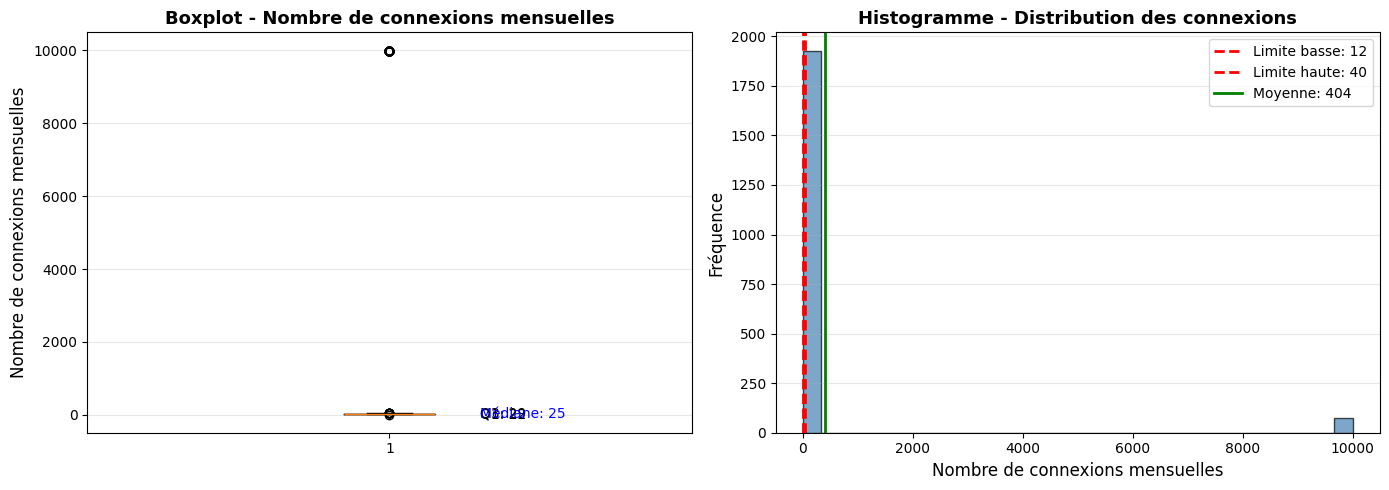

In [13]:
# Créer une figure avec plusieurs graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot simple
axes[0].boxplot(df['nb_connexions_mensuelles'], vert=True)
axes[0].set_ylabel('Nombre de connexions mensuelles', fontsize=12)
axes[0].set_title('Boxplot - Nombre de connexions mensuelles', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Ajouter les statistiques sur le graphique
axes[0].text(1.15, Q1, f'Q1: {Q1:.0f}', fontsize=10, va='center')
axes[0].text(1.15, Q3, f'Q3: {Q3:.0f}', fontsize=10, va='center')
axes[0].text(1.15, df['nb_connexions_mensuelles'].median(), f'Médiane: {df["nb_connexions_mensuelles"].median():.0f}', fontsize=10, va='center', color='blue')

# Histogramme avec courbe de distribution
axes[1].hist(df['nb_connexions_mensuelles'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(limite_basse, color='red', linestyle='--', linewidth=2, label=f'Limite basse: {limite_basse:.0f}')
axes[1].axvline(limite_haute, color='red', linestyle='--', linewidth=2, label=f'Limite haute: {limite_haute:.0f}')
axes[1].axvline(df['nb_connexions_mensuelles'].mean(), color='green', linestyle='-', linewidth=2, label=f'Moyenne: {df["nb_connexions_mensuelles"].mean():.0f}')
axes[1].set_xlabel('Nombre de connexions mensuelles', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Histogramme - Distribution des connexions', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

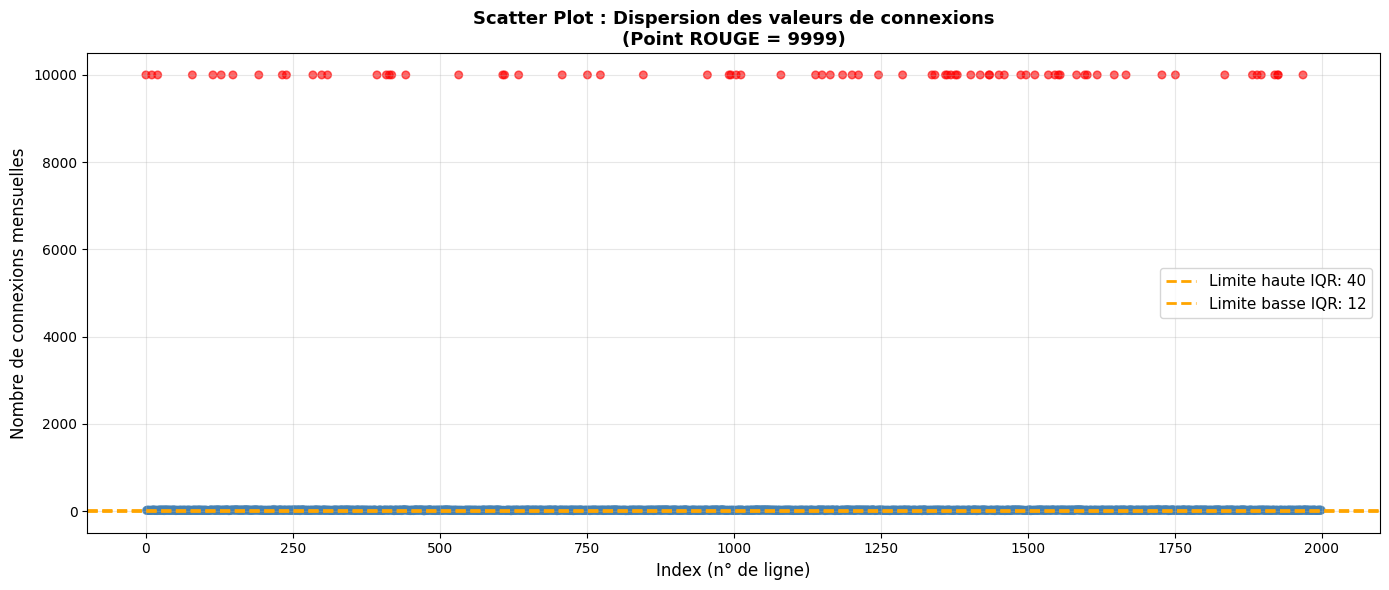

In [14]:
# Créer une figure simple
fig, ax = plt.subplots(figsize=(14, 6))

# Colorer différemment le point 9999 (ROUGE)
couleurs = ['red' if x == 9999 else 'steelblue' for x in df['nb_connexions_mensuelles']]

# Afficher le scatter plot
ax.scatter(range(len(df)), df['nb_connexions_mensuelles'], c=couleurs, alpha=0.6, s=30)

# Ajouter les limites IQR
ax.axhline(y=limite_haute, color='orange', linestyle='--', linewidth=2, label=f'Limite haute IQR: {limite_haute:.0f}')
ax.axhline(y=limite_basse, color='orange', linestyle='--', linewidth=2, label=f'Limite basse IQR: {limite_basse:.0f}')

# Labels et titre
ax.set_xlabel('Index (n° de ligne)', fontsize=12)
ax.set_ylabel('Nombre de connexions mensuelles', fontsize=12)
ax.set_title('Scatter Plot : Dispersion des valeurs de connexions\n(Point ROUGE = 9999)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# afficher combien de valeur 9999 il y a par rapport au total
nb_9999 = (df['nb_connexions_mensuelles'] == 9999).sum()
total = len(df)
pourcentage = (nb_9999 / total * 100) if total > 0 else 0
print(f"\nNombre de valeurs 9999 : {nb_9999} sur {total} ({pourcentage:.2f}%)")



Nombre de valeurs 9999 : 76 sur 2000 (3.80%)


### RECOMMANDATION :

  - Supprimer les valeurs 9999
    - Raison : Erreur d'entrée/bug, pas de données réelles
    - Perte : 76 lignes seulement (3.80%)
    - Bénéfice : Modèles plus fiables et représentation réelle

In [16]:
# Suppression des valeurs 9999

print(f"Avant suppression : {len(df)} lignes")
df = df[df['nb_connexions_mensuelles'] != 9999]
print(f"Après suppression : {len(df)} lignes")
print(f"Lignes supprimées : {2021 - len(df)}")

print("\n Données nettoyées des valeurs aberrantes")

Avant suppression : 2000 lignes
Après suppression : 1924 lignes
Lignes supprimées : 97

 Données nettoyées des valeurs aberrantes


## 7 : ANONYMISATION DES DONNÉES

In [17]:
print("\n" + "="*80)
print("ANONYMISATION - SUPPRESSION DES COLONNES SENSIBLES")
print("="*80)

# Créer une copie pour l'anonymisation
df_anonymise = df.copy()

# Colonnes à supprimer (identifiants directs)
colonnes_a_supprimer = ['nom_complet', 'dernier_dispositif', 'derniere_connexion']

print(f"\nColonnes avant anonymisation : {len(df_anonymise.columns)}")
print(f"Colonnes : {list(df_anonymise.columns)}")

df_anonymise = df_anonymise.drop(columns=colonnes_a_supprimer)

print(f"\nColonnes après anonymisation : {len(df_anonymise.columns)}")
print(f"Colonnes : {list(df_anonymise.columns)}")
print(f"\nColonnes supprimées : {colonnes_a_supprimer}")
print(f"\n✓ Anonymisation complétée")

# Afficher un aperçu
print(f"\nAperçu du dataset anonymisé :")
print(df_anonymise.head())


ANONYMISATION - SUPPRESSION DES COLONNES SENSIBLES

Colonnes avant anonymisation : 13
Colonnes : ['nom_complet', 'genre', 'pays', 'age', 'revenu_annuel', 'type_abonnement', 'duree_abonnement_mois', 'nb_connexions_mensuelles', 'dernier_dispositif', 'derniere_connexion', 'churn', 'jour_semaine', 'mois']

Colonnes après anonymisation : 10
Colonnes : ['genre', 'pays', 'age', 'revenu_annuel', 'type_abonnement', 'duree_abonnement_mois', 'nb_connexions_mensuelles', 'churn', 'jour_semaine', 'mois']

Colonnes supprimées : ['nom_complet', 'dernier_dispositif', 'derniere_connexion']

✓ Anonymisation complétée

Aperçu du dataset anonymisé :
   genre      pays   age  revenu_annuel type_abonnement  \
1  Femme  Belgique  50.0       43826.83        Standard   
2  Femme   Algérie  20.0       33698.53        Familial   
3  Femme    France  57.0       62953.26        Standard   
4  Femme   Algérie  57.0       43161.83             NaN   
5  Femme     Maroc  68.0       59701.25         Premium   

   dure

In [18]:
# REGROUPER L'ÂGE EN TRANCHES D'ÂGE
# Créer des tranches d'âge
df_anonymise['age_groupe'] = pd.cut(df_anonymise['age'], 
                                     bins=[0, 20, 30, 40, 50, 60, 100],
                                     labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+'])

print("Distribution des groupes d'âge :")
print(df_anonymise['age_groupe'].value_counts().sort_index())
print("\nExemples avant/après :")
print(df[['age']].head(10))
print(df_anonymise[['age_groupe']].head(10))
# Supprimer la colonne age original
df_anonymise = df_anonymise.drop(columns=['age'])
print("\nColonne 'age' supprimée, 'age_groupe' créée")


Distribution des groupes d'âge :
age_groupe
<20      103
20-30    340
30-40    351
40-50    360
50-60    362
60+      313
Name: count, dtype: int64

Exemples avant/après :
     age
1   50.0
2   20.0
3   57.0
4   57.0
5   68.0
6   52.0
7   49.0
8   59.0
9   26.0
11  34.0
   age_groupe
1       40-50
2         <20
3       50-60
4       50-60
5         60+
6       50-60
7       40-50
8       50-60
9       20-30
11      30-40

Colonne 'age' supprimée, 'age_groupe' créée


In [19]:
# Paramètres de perturbation
bruit_percentage = 15  # Ajouter un bruit de ±15%
np.random.seed(0)  # Pour la reproductibilité

# Créer une copie du revenu original pour la perturbation
revenu_original = df_anonymise['revenu_annuel'].copy()

# Identifier les lignes avec des valeurs valides (non-NaN)
mask_valides = ~revenu_original.isna()
nb_valides = mask_valides.sum()
nb_nan = revenu_original.isna().sum()

print(f"Statistiques avant perturbation :")
print(f"  - Valeurs valides : {nb_valides}")
print(f"  - Valeurs NaN : {nb_nan}")
print()

# Générer des facteurs de bruit aléatoires pour les valeurs valides
facteurs_bruit = np.ones(len(revenu_original))
facteurs_bruit[mask_valides] = np.random.uniform(
    1 - bruit_percentage/100, 
    1 + bruit_percentage/100, 
    size=nb_valides
)

# Appliquer la perturbation seulement aux valeurs valides
df_anonymise['revenu_annuel'] = revenu_original * facteurs_bruit

# Les NaN restent NaN
df_anonymise.loc[~mask_valides, 'revenu_annuel'] = np.nan

print("Distribution avant/après perturbation :")
print(f"\n  Statistiques AVANT perturbation (valeurs valides uniquement) :")
print(f"    Min     : {revenu_original[mask_valides].min():.2f}")
print(f"    Max     : {revenu_original[mask_valides].max():.2f}")
print(f"    Moyenne : {revenu_original[mask_valides].mean():.2f}")
print(f"    Médiane : {revenu_original[mask_valides].median():.2f}")
print(f"    Écart-type : {revenu_original[mask_valides].std():.2f}")

print(f"\n  Statistiques APRÈS perturbation (valeurs valides uniquement) :")
revenu_perturbe_valides = df_anonymise.loc[mask_valides, 'revenu_annuel']
print(f"    Min     : {revenu_perturbe_valides.min():.2f}")
print(f"    Max     : {revenu_perturbe_valides.max():.2f}")
print(f"    Moyenne : {revenu_perturbe_valides.mean():.2f}")
print(f"    Médiane : {revenu_perturbe_valides.median():.2f}")
print(f"    Écart-type : {revenu_perturbe_valides.std():.2f}")

print("\nExemples avant/après perturbation :")
exemples_idx = [0, 1, 2, 3, 4]
for idx in exemples_idx:
    rev_orig = revenu_original.iloc[idx]
    rev_pert = df_anonymise.iloc[idx]['revenu_annuel']
    if pd.notna(rev_orig) and pd.notna(rev_pert):
        diff = rev_pert - rev_orig
        pct_change = (diff / rev_orig) * 100
        print(f"  Revenu {rev_orig:>10.2f} → {rev_pert:>10.2f} (variation: {pct_change:+6.2f}%)")
    else:
        print(f"  Revenu {rev_orig} → {rev_pert} (NaN traité)")

print("\n✓ Perturbation du revenu appliquée avec succès")


Statistiques avant perturbation :
  - Valeurs valides : 1783
  - Valeurs NaN : 141

Distribution avant/après perturbation :

  Statistiques AVANT perturbation (valeurs valides uniquement) :
    Min     : 407.07
    Max     : 78917.12
    Moyenne : 40256.44
    Médiane : 40720.77
    Écart-type : 11679.81

  Statistiques APRÈS perturbation (valeurs valides uniquement) :
    Min     : 408.55
    Max     : 77493.89
    Moyenne : 40239.93
    Médiane : 40396.50
    Écart-type : 12036.87

Exemples avant/après perturbation :
  Revenu   43826.83 →   44468.63 (variation:  +1.46%)
  Revenu   33698.53 →   35874.00 (variation:  +6.46%)
  Revenu   62953.26 →   64894.05 (variation:  +3.08%)
  Revenu   43161.83 →   43743.00 (variation:  +1.35%)
  Revenu   59701.25 →   58333.88 (variation:  -2.29%)

✓ Perturbation du revenu appliquée avec succès


## 8 : SAUVEGARDE DES RÉSULTATS

In [20]:
# Sauvegarder le dataset nettoyé
df.to_csv('dataset_churn_nettoyee.csv', index=False)
print("Dataset nettoyée sauvegardé : 'dataset_churn_nettoyee.csv'")

# Sauvegarder le dataset anonymisé
df_anonymise.to_csv('dataset_churn_anonymisee.csv', index=False)
print("Dataset anonymisée sauvegardée : 'dataset_churn_anonymisee.csv'")

print("\n" + "="*80)
print("RÉSUMÉ FINAL")
print("="*80)
print(f"\nDataset nettoyée :")
print(f"  Dimensions : {df.shape}")
print(f"  Colonnes : {list(df.columns)}")

print(f"\nDataset anonymisée :")
print(f"  Dimensions : {df_anonymise.shape}")
print(f"  Colonnes : {list(df_anonymise.columns)}")

print(f"\n Processus terminé avec succès!")

Dataset nettoyée sauvegardé : 'dataset_churn_nettoyee.csv'
Dataset anonymisée sauvegardée : 'dataset_churn_anonymisee.csv'

RÉSUMÉ FINAL

Dataset nettoyée :
  Dimensions : (1924, 13)
  Colonnes : ['nom_complet', 'genre', 'pays', 'age', 'revenu_annuel', 'type_abonnement', 'duree_abonnement_mois', 'nb_connexions_mensuelles', 'dernier_dispositif', 'derniere_connexion', 'churn', 'jour_semaine', 'mois']

Dataset anonymisée :
  Dimensions : (1924, 10)
  Colonnes : ['genre', 'pays', 'revenu_annuel', 'type_abonnement', 'duree_abonnement_mois', 'nb_connexions_mensuelles', 'churn', 'jour_semaine', 'mois', 'age_groupe']

 Processus terminé avec succès!


## 9 : PRÉPARATION POUR LA MODÉLISATION

In [21]:
print("separation des variables numeriques et categoriques\n")

X = df_anonymise.copy()
y = X.pop('churn') if 'churn' in X.columns else None

print(f"dimensions X : {X.shape}")
print(f"colonnes : {list(X.columns)}\n")

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"variables numeriques : {numeric_features}")
print(f"variables categoriques : {categorical_features}")

separation des variables numeriques et categoriques

dimensions X : (1924, 9)
colonnes : ['genre', 'pays', 'revenu_annuel', 'type_abonnement', 'duree_abonnement_mois', 'nb_connexions_mensuelles', 'jour_semaine', 'mois', 'age_groupe']

variables numeriques : ['revenu_annuel', 'duree_abonnement_mois', 'nb_connexions_mensuelles']
variables categoriques : ['genre', 'pays', 'type_abonnement']


C:\Users\Marou\AppData\Local\Temp\ipykernel_2132\1017603257.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("\ncreation du columntransformer\n")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("columntransformer cree")
print(f"variables numeriques : {numeric_features}")
print(f"variables categoriques : {categorical_features}")


creation du columntransformer

columntransformer cree
variables numeriques : ['revenu_annuel', 'duree_abonnement_mois', 'nb_connexions_mensuelles']
variables categoriques : ['genre', 'pays', 'type_abonnement']


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("\ncréation des pipelines avec classifieurs\n")

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

print("3 pipelines crées : RandomForest, KNN, SVM")



création des pipelines avec classifieurs

3 pipelines crées : RandomForest, KNN, SVM


In [24]:
print("\nstructure du pipeline random forest :\n")

for idx, (name, step) in enumerate(pipeline_rf.steps, 1):
    print(f"{idx}. {name}")
    if name == 'preprocessor':
        for trans_name, transformer, cols in step.transformers:
            print(f"   - {trans_name}: {cols}")
    else:
        print(f"   - type: {type(step).__name__}")
        print(f"   - n_estimators: {step.n_estimators}")

print(f"\netapes: {list(pipeline_rf.named_steps.keys())}")


structure du pipeline random forest :

1. preprocessor
   - num: ['revenu_annuel', 'duree_abonnement_mois', 'nb_connexions_mensuelles']
   - cat: ['genre', 'pays', 'type_abonnement']
2. classifier
   - type: RandomForestClassifier
   - n_estimators: 100

etapes: ['preprocessor', 'classifier']
